In [2]:
!pip install tensorflow_datasets

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached docstring_parser-0.17.0-py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   --------------- ------------------------ 2.1/5.3 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------  5.2/5.3 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 5.3/5.3 MB 16.5 MB/s eta 0:00:00
Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
Using cached docstring_parser-0.17.0-py3-none-any.whl (36 kB)
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21545 sha256=1abdc6fe87c7ea507f8870dd2497da1a3672450b136e1cf9e51ea699771dd336
  Stored in directory: c:\users\msi-nb\appdata\local\pip\cache\wheels\8f\46\1c\1f4e5d73a20eb816ead5014e97cdeb3928cf314fc46c7bab61
Successfully built promise

   -----------

  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'promise'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds
import os
from tqdm.notebook import tqdm

In [10]:
#載入資料集
# tfds.load?
(ds_train, ds_test), info = tfds.load('stanford_dogs', split=['train', 'test'], with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\MSI-NB\tensorflow_datasets\stanford_dogs\incomplete.DOMVCO_0.2.0\stanford_dogs-train.tfreco…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\MSI-NB\tensorflow_datasets\stanford_dogs\incomplete.DOMVCO_0.2.0\stanford_dogs-test.tfrecor…

Dataset stanford_dogs downloaded and prepared to C:\Users\MSI-NB\tensorflow_datasets\stanford_dogs\0.2.0. Subsequent calls will reuse this data.


In [ ]:
class_name_bytes = info.features['label'].names
class_name_bytes

In [16]:
#顯示資料及資訊
print(f"品種數:{info.features['label'].num_classes}")
print(f"訓練資料集:{info.splits['train'].num_examples}")
print(f"測試資料集:{info.splits['test'].num_examples}")
print(f"前幾種類型:{class_name_bytes[:5]}")
class_names = [name[10:] for name in class_name_bytes]
print(f"前幾種類型(去除品號):{class_names[:5]}")

品種數:120
訓練資料集:12000
測試資料集:8580
前幾種類型:['n02085620-chihuahua', 'n02085782-japanese_spaniel', 'n02085936-maltese_dog', 'n02086079-pekinese', 'n02086240-shih-tzu']
前幾種類型(去除品號):['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih-tzu']


In [17]:
from tensorflow_datasets.core.utils.file_utils import expand_glob
try:
  target_substring = 'maltese_dog'
  maltese_dog_index = [i for i, name in enumerate(class_names) if target_substring in name.lower()]
  print(f"符合關鍵字的類別的索引:{maltese_dog_index}")
except ValueError:
  print(f"找不到該品種名稱")
  maltese_dog_index = 0


符合關鍵字的類別的索引:[2]


In [18]:
maltese_images = []
for images, label in tqdm(ds_train.as_numpy_iterator(), total=info.splits['train'].num_examples):
  if label in maltese_dog_index:
    maltese_images.append(images)
  if len(maltese_images) >= 5:
    break
    

  0%|          | 0/12000 [00:00<?, ?it/s]

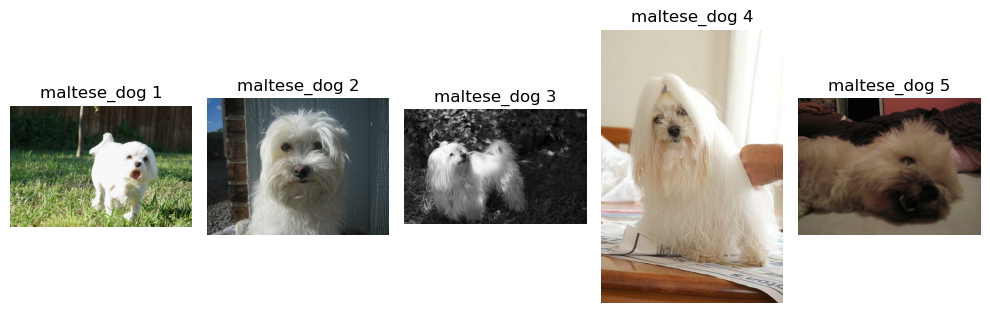

In [19]:
plt.figure(figsize=(10,5))
for i, img_data in enumerate(maltese_images):
  if i >=5:
    break
  plt.subplot(1,5,i+1)
  plt.imshow(img_data)
  plt.title(f'maltese_dog {i+1}')
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#調用2015年冠軍模型 ResNet50
model_resnet50 = tf.keras.applications.ResNet50(weights='imagenet', include_top=True, input_shape=(224,224,3))
model_resnet50.summary()

In [21]:
#使用ResNet50預測
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
預測類型前五名:
第1名:Maltese_dog (機率:0.94)
第2名:Lhasa (機率:0.04)
第3名:Pekinese (機率:0.02)
第4名:Shih-Tzu (機率:0.01)
第5名:Japanese_spaniel (機率:0.00)


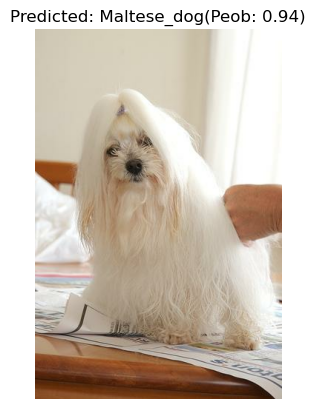

In [22]:
if len(maltese_images) > 3:
  image_to_predict = maltese_images[3]
  img_tensor = tf.convert_to_tensor(image_to_predict, dtype=tf.float32)
  img_resize = tf.image.resize(img_tensor, (224,224))
  img_array_expanded = tf.expand_dims(img_resize, axis=0) #擴充維度以符合ResNet50輸入
  preprocessed_img = preprocess_input(img_array_expanded) #正規化
  predictions = model_resnet50.predict(preprocessed_img)
  decoded_predictions = decode_predictions(predictions, top=5)[0]
  print("預測類型前五名:")
  for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"第{i+1}名:{label} (機率:{score:.2f})")
  plt.imshow(image_to_predict.astype('uint8'))
  plt.title(f"Predicted: {decoded_predictions[0][1]}(Peob: {decoded_predictions[0][2]:.2f})")
  plt.axis('off')
  plt.show()
else:
  print("照片不足")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
預測類型前五名:
第1名:Chihuahua (機率:0.94)
第2名:toy_terrier (機率:0.05)
第3名:Mexican_hairless (機率:0.00)
第4名:French_bulldog (機率:0.00)
第5名:miniature_pinscher (機率:0.00)


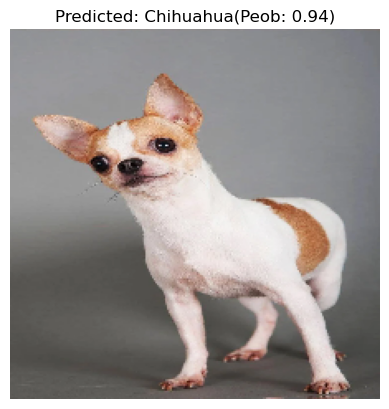

In [24]:
from tensorflow.keras.preprocessing.image import load_img
#使用resnet50預測自己上傳的照片
image_path = '004.jpg'
img = load_img(image_path, target_size=(224,224))
img_array = img_to_array(img)
img_array_expanded = np.expand_dims(img_array, axis=0)
preprocessed_img = preprocess_input(img_array_expanded)
predictions = model_resnet50.predict(preprocessed_img)
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("預測類型前五名:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
  print(f"第{i+1}名:{label} (機率:{score:.2f})")
plt.imshow(img)
plt.title(f"Predicted: {decoded_predictions[0][1]}(Peob: {decoded_predictions[0][2]:.2f})")
plt.axis('off')
plt.show()

In [26]:
!pip install gradio

   ---------------------------------------- 0.0/23.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.0 MB ? eta -:--:--
   - -------------------------------------- 0.8/23.0 MB 1.7 MB/s eta 0:00:14
   --- ------------------------------------ 1.8/23.0 MB 2.8 MB/s eta 0:00:08
   ------ --------------------------------- 3.7/23.0 MB 4.3 MB/s eta 0:00:05
   ------------ --------------------------- 7.1/23.0 MB 6.8 MB/s eta 0:00:03
   ----------------- ---------------------- 10.0/23.0 MB 8.4 MB/s eta 0:00:02
   ------------------- -------------------- 11.0/23.0 MB 7.8 MB/s eta 0:00:02
   --------------------- ------------------ 12.1/23.0 MB 7.4 MB/s eta 0:00:02
   ----------------------- ---------------- 13.4/23.0 MB 7.3 MB/s eta 0:00:02
   ------------------------- -

In [27]:
import gradio as gr
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import tensorflow as tf

In [28]:
if 'model_resnet50' not in locals():
  model_resnet50 = tf.keras.applications.ResNet50(weights='imagenet', include_top=True, input_shape=(224,224,3))

In [29]:
def predict_image_gradio(input_image):
  img_array = img_to_array(input_image)
  img_resized = tf.image.resize(input_image, (224,224))
  img_array_expanded = np.expand_dims(img_resized, axis=0)
  preprocessed_img = preprocess_input(img_array_expanded)
  predictions = model_resnet50.predict(preprocessed_img)
  decoded_predictions = decode_predictions(predictions, top=5)[0]
  output_labels = {label:float(score) for (_, label,score) in decoded_predictions}
  return output_labels


In [30]:
iface = gr.Interface(fn=predict_image_gradio, inputs=gr.Image(type='pil', label='上傳照片'), outputs=gr.Label(num_top_classes=5),
                     title='Image Recognition with ResNet50', description='upload an image')
iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


In [33]:
maltese_dir = 'maltese_dir'
image_paths = [
    os.path.join(maltese_dir, fname)
    for fname in os.listdir(maltese_dir)
    if fname.lower().endswith(('.jpg','jpeg','png'))
]
print(f'載入了{len(image_paths)}張照片。')

載入了4張照片。


In [34]:
from tensorflow.keras.preprocessing import image
if len(image_paths) == 0:
  print('沒有照片')
else:
  top1_correct = 0
  top5_correct = 0
  total = len(image_paths)
  for image_path in tqdm(image_paths, desc="預測"):
    img = image.load_img(image_path, target_size=(224,224))
    img_array = img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(img_array_expanded)
    preds = model_resnet50.predict(preprocessed_img, verbose=0)
    decoded = decode_predictions(preds, top=5)[0]
    labels = [label.lower() for (_,label,_) in decoded]
    if 'maltese_dog' in label:
      top5_correct +=1
      if label[0] == 'malrese_dog':
        top1_correct += 1
    print(f"圖片:{os.path.basename(image_path)}")
    for i , (imagenet_id, label, score) in enumerate(decoded):
      print(f"Top-{i+1} : {label} (機率:{score:.2f}")
  print(f"top-1命中{top1_correct}次")
  print(f"top-5命中{top5_correct}次")



預測:   0%|          | 0/4 [00:00<?, ?it/s]

圖片:001.jpg
Top-1 : Maltese_dog (機率:0.42
Top-2 : toy_poodle (機率:0.25
Top-3 : teddy (機率:0.20
Top-4 : Shih-Tzu (機率:0.09
Top-5 : miniature_poodle (機率:0.01
圖片:002.jpg
Top-1 : Persian_cat (機率:0.98
Top-2 : lynx (機率:0.00
Top-3 : Angora (機率:0.00
Top-4 : Samoyed (機率:0.00
Top-5 : shower_curtain (機率:0.00
圖片:003.jpg
Top-1 : dingo (機率:0.79
Top-2 : basenji (機率:0.14
Top-3 : chow (機率:0.01
Top-4 : red_wolf (機率:0.01
Top-5 : German_shepherd (機率:0.01
圖片:004.jpg
Top-1 : Chihuahua (機率:0.94
Top-2 : toy_terrier (機率:0.05
Top-3 : Mexican_hairless (機率:0.00
Top-4 : French_bulldog (機率:0.00
Top-5 : miniature_pinscher (機率:0.00
top-1命中0次
top-5命中0次


In [35]:
#辨識 stand
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
from tqdm import tqdm
(ds_train, ds_test), info = tfds.load(
    'stanford_dogs',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

class_names_bytes = info.features['label'].names
# 這裡做 [10:] 是為了去除前面的編號 (例如: "n02085936-Maltese_dog")
class_names = [name[10:] for name in class_names_bytes] 
target_substring = "maltese"

# 搜尋包含 "maltese" 的類別索引
maltese_dog_index = [i for i, name in enumerate(class_names) if target_substring in name.lower()]
print(f"Maltese 類別索引值: {maltese_dog_index}")

Maltese 類別索引值: [2]


In [36]:
IMG_SIZE = 224
def filter_data(dataset, target_label_index, is_target_class=True, max_count=100):
  images=[]
  labels=[]
  for image,label in dataset:
    is_target = label.numpy() in target_label_index if isinstance(target_label_index, list) else label == target_label_index
    if(is_target == is_target_class):
      image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
      images.append(image)
      labels.append(1 if is_target_class else 0)
      if len(images) >= max_count:
        break
  return images, labels

In [37]:
print("正樣本")
maltese_images, maltese_labels = filter_data(ds_train, maltese_dog_index, True, 100)
print("負樣本")
other_images, other_labels = filter_data(ds_train, maltese_dog_index, False, 100)


正樣本
負樣本


In [38]:
all_images = np.array(maltese_images + other_images)
all_labels = np.array(maltese_labels + other_labels)
indices = np.arange(len(all_images))
np.random.shuffle(indices)
all_images = all_images[indices]
all_labels = all_labels[indices]
all_images = tf.keras.applications.resnet50.preprocess_input(all_images)
split_index = int(0.8 * len(all_images))
x_train, x_test = all_images[:split_index], all_images[split_index:]
y_train, y_test = all_labels[:split_index], all_labels[split_index:]
print(len(x_train), len(x_test))

160 40


In [39]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights = 'imagenet',
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'
)
base_model.trainable = False
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [40]:
history = model.fit(x_train, y_train, epochs=3, batch_size=20, validation_split=0.2)

Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 522ms/step - accuracy: 0.6875 - loss: 0.8590 - val_accuracy: 0.9062 - val_loss: 0.3072
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 0.9531 - loss: 0.1204 - val_accuracy: 0.9688 - val_loss: 0.0959
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.9688 - loss: 0.0866 - val_accuracy: 1.0000 - val_loss: 0.0426


In [41]:
loss,acc = model.evaluate(x_test, y_test)
print(f"{loss:.3f}")
print(f"{acc:.3f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.9750 - loss: 0.0952
0.095
0.975
